# LOAD LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from datetime import datetime
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet

# CONFIGURATION

In [2]:
START_DATE, END_DATE = '2023-11-08', '2025-06-05'
TARGET_FLUX = 'NEE'
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
CROSSVAL_SPLIT = 'time_blocks_eliza' # options: 'shuffle' or 'kfold' or 'time_blocks_eliza'
N_FOLDS = 10
PARCEL_CERTAIN = False # choose if to use in the training also values coming from mixed contribution
LOG_TRANSFORM = False
UNDERSAMPLE = False
ADD_ID = True
PERMUTATION_SEL = False
RFE_SEL = True
DAY_NIGHT = 'NIGHT'
ADD_TRT = False
ADD_CANOPY = False

# LOAD DATA

In [3]:
data_main = fluxes = load_parquet(filepath=r"81.1.1_GapFillingDataset.parquet")
data_main = data_main.loc[START_DATE:END_DATE].copy()

# Add an id column to account for the proximity of values as the timestamp is continuous without gaps
if ADD_ID:
    data_main['id'] = range(0, len(data_main))
    print("\nAdded 'id' variable --> indexing number starting from zero")
else:
    print('\nNot using index variable')

data_main

Loaded .parquet file 81.1.1_GapFillingDataset.parquet (0.341 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 

Added 'id' variable --> indexing number starting from zero


,NEE_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,parcel,parcel_certainty,trt,SW_IN_POT,prec,ta,ppfd,sw_in,rh,...,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,LAI,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,NaN,-0.111997,-3.231648,NaN,NaN,-3.231648,B,certain,1.0,0.0,0.0,5.333333,0.0,0.0,79.833333,...,-0.193433,-0.188894,0.055964,-1.641550,-0.086146,0.576043,0.0,0.0,2.185170,0.986663,29.0,22.0,0.300700,5.004348,0
2023-11-08 00:45:00,NaN,0.100302,NaN,NaN,0.100302,NaN,B,certain,1.0,0.0,0.0,5.966667,0.0,0.0,77.500000,...,-0.051464,0.009568,0.016644,-2.340741,0.001028,0.291943,0.0,0.0,2.179702,0.983564,29.0,22.0,0.300704,5.004376,1
2023-11-08 01:15:00,NaN,0.239428,NaN,NaN,0.239428,NaN,B,certain,1.0,0.0,0.0,5.833333,0.0,0.0,77.366667,...,-0.146880,0.084459,0.138010,-0.829823,0.242660,0.618842,0.0,0.0,2.174248,0.980476,29.0,22.0,0.300709,5.004405,2
2023-11-08 01:45:00,NaN,-0.184917,6.746138,NaN,NaN,NaN,B,certain,1.0,0.0,0.0,5.866667,0.0,0.0,77.100000,...,-0.234554,-0.023746,0.307449,-0.724752,0.260016,0.686303,0.0,0.0,2.168807,0.977400,29.0,22.0,0.300714,5.004433,3
2023-11-08 02:15:00,NaN,0.358358,3.168362,NaN,0.358358,3.168362,B,certain,1.0,0.0,0.0,5.766667,0.0,0.0,77.166667,...,-0.187335,-0.028905,0.178615,-0.724348,0.032634,0.695635,0.0,0.0,2.163380,0.974334,29.0,22.0,0.300718,5.004462,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,0.0,15.833333,0.0,0.0,84.166667,...,-1.379082,-1.916712,-1.061214,-4.208609,-5.629534,-3.817729,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27643
2025-06-05 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,0.0,15.733333,0.0,0.0,83.833333,...,-1.091476,-1.879544,-0.962736,-4.909742,-6.854152,-4.700644,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27644
2025-06-05 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,0.0,16.200000,0.0,0.0,78.066667,...,-1.190896,-1.739450,-0.961502,-4.913663,-6.580284,-4.667567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27645


# SUBSET DAY/NIGHT

In [4]:
if DAY_NIGHT == 'DAY':
    data_main = data_main[data_main['sw_in'] > 20].copy()
    print('Using only daytime data (SW_IN_POT > 20)')
else:
    data_main = data_main[data_main['sw_in'] <= 20].copy()
    print('Using only nighttime data (SW_IN_POT <= 20)')

Using only nighttime data (SW_IN_POT <= 20)


# CLEAN DATA

In [5]:
TARGET = f'{TARGET_FLUX}_L3.3_CUT_50_QCF0'
print(f'The target variable is {TARGET}')

mean_nan_size = (
    data_main[TARGET]
    .isna()
    .ne(data_main[TARGET].isna().shift())
    .cumsum()
    .where(data_main[TARGET].isna())
    .dropna()
    .value_counts()
    .mean()
)
print("\nMean size of consecutive NaNs in the target variable:", mean_nan_size)

# Remove NAs
data = data_main[data_main[TARGET].notna()].copy()

# Keep only data where we are sure about parcel attribution
if PARCEL_CERTAIN:
    data = data[data['parcel_certainty'] == 'certain'].copy()
    print('\nKeeping only data when we are highly confident on the parcel attribution')
else:
    print('\nKeeping also data from mixed parcel contribution')

# Remove canopy variables
if ADD_CANOPY==False:
    prefix = ('LAI', 'can_height')
    to_drop = [c for c in data.columns if c.startswith(prefix)]
    data.drop(columns=to_drop, inplace=True)
    print(f"\nDropped {len(to_drop)} canopy columns: {to_drop}")

# Remove teatment variable if ADD_TRT==False
if ADD_TRT==False:
    data.drop(columns='trt', inplace=True)
    print('\nRemoved the treatment variable (trt)')
else:
    print('\nKeeping the treatment variable (trt)')

# Drop variables related to specific parcels
to_drop = [c for c in data.columns if 'parcel' in c]
data.drop(columns=to_drop, inplace=True)
print(f"\nDropped {len(to_drop)} parcel-specific columns: {to_drop}")

# Keep only variables of the chosen categories
# prefix = ('wfps', 'ts', 'prec', 'GPP', 'n_decay', 'NEE', 'Reco', 'timesince', TARGET)
# to_keep = [c for c in data.columns if c.startswith(prefix)]
# data = data[to_keep].copy()
# to_remove = [c for c in data.columns if 'parcelA' in c or 'parcelB' in c]
# data.drop(columns=to_remove, inplace=True)

# Remove any flux variable with target flux except for the target itself
to_drop = [col for col in data.columns if TARGET_FLUX in col]
# Leave the target!
to_drop.remove(TARGET)
data.drop(columns=to_drop, inplace=True)

def clean_data(df, threshold=0.05):
    """Remove columns with too many missing values and non-numeric columns."""
    dropped_missing = df.columns[df.isna().mean() > threshold].tolist()
    df = df.drop(columns=dropped_missing)
    dropped_non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
    df = df.select_dtypes(include=[np.number])
    print(f"\nDropped {len(dropped_missing)} due to missing values: {dropped_missing}")
    print(f"\nDropped {len(dropped_non_numeric)} non-numeric columns: {dropped_non_numeric}")
    
    return df

data = clean_data(data)

data

The target variable is NEE_L3.3_CUT_50_QCF0

Mean size of consecutive NaNs in the target variable: 7.809669992325403

Keeping also data from mixed parcel contribution

Dropped 6 canopy columns: ['LAI_parcelA', 'LAI_parcelB', 'can_height_parcelA', 'can_height_parcelB', 'LAI', 'can_height']

Removed the treatment variable (trt)

Dropped 14 parcel-specific columns: ['parcel', 'parcel_certainty', 'n_decay_linear_parcelA', 'n_decay_linear_parcelB', 'n_decay_logistic_parcelA', 'n_decay_logistic_parcelB', 'n_decay_exponential_parcelA', 'n_decay_exponential_parcelB', 'n_decay_lognormal_parcelA', 'n_decay_lognormal_parcelB', 'n_decay_timed_parcelA', 'n_decay_timed_parcelB', 'timesince_fert_parcelA', 'timesince_fert_parcelB']

Dropped 4 due to missing values: ['FN2O_L3.3_CUT_50_QCF', 'FCH4_L3.3_CUT_50_QCF', 'FN2O_L3.3_CUT_50_QCF0', 'FCH4_L3.3_CUT_50_QCF0']

Dropped 1 non-numeric columns: ['crop_type']


,NEE_L3.3_CUT_50_QCF0,SW_IN_POT,prec,ta,ppfd,sw_in,rh,timesince_prec,vpd,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,...,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-22 15:15:00,1.427440,277.0860,0.000,3.160000,32.345077,16.666667,91.736666,8.0,0.063359,4.183253,7.010251,7.412297,48.625304,56.253294,46.223418,...,0.524015,1.260472,-0.410443,-0.109809,0.746184,-0.980362,0.760726,1.700008,0.0,0.0,0.0,0.0,0.0,30.0,702
2023-11-22 15:45:00,1.002807,189.1070,0.000,2.983333,33.735705,17.333333,91.379999,9.0,0.065269,4.265979,7.243870,7.360901,48.839780,56.134146,46.352603,...,0.608953,1.644100,-1.043817,-0.057817,0.555294,-0.439485,0.204556,1.585453,0.0,0.0,0.0,0.0,0.0,30.0,703
2023-11-22 16:15:00,1.405169,91.8094,0.017,2.693333,10.790348,6.333333,92.029999,0.0,0.059114,4.135543,7.615964,7.423162,48.680861,56.298484,45.867126,...,0.529076,1.554913,-0.150715,0.065239,0.717598,-0.121607,-0.801852,1.026511,0.0,0.0,0.0,0.0,0.0,30.0,704
2023-11-22 16:45:00,1.052631,20.5151,0.017,2.593333,2.446582,2.333333,91.653332,0.0,0.061468,3.896637,6.400778,7.446704,48.255124,56.380921,45.857251,...,0.647230,1.133467,-0.145347,0.291490,0.747449,-0.333135,0.310568,0.461955,0.0,0.0,0.0,0.0,0.0,30.0,705
2023-11-22 17:15:00,1.088705,0.0000,0.000,2.506667,0.000000,0.000000,90.480000,1.0,0.069676,3.679415,6.489111,8.012857,48.267731,56.433886,45.820050,...,1.371347,0.552128,0.154700,0.345785,0.862861,-0.899240,-0.037856,0.678603,0.0,0.0,0.0,0.0,0.0,30.0,706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,10.578562,0.0000,0.017,15.693333,0.000000,0.000000,82.700000,0.0,0.308913,18.192778,18.566111,17.300000,47.839156,49.728310,45.159003,...,-0.862990,-1.240195,-0.138894,-0.501428,-0.865616,-0.130630,-0.951387,-1.460515,0.0,0.0,0.0,0.0,0.0,30.0,27595
2025-06-04 22:15:00,9.416519,0.0000,0.034,15.516667,0.000000,0.000000,84.423333,0.0,0.275008,18.041666,18.451111,17.300000,47.841354,49.728310,45.154540,...,-0.850980,-1.201306,-0.115306,-0.455520,-0.859899,-0.075635,-0.878298,-1.447001,0.0,0.0,0.0,0.0,0.0,30.0,27596
2025-06-04 22:45:00,10.095010,0.0000,0.425,15.660000,0.000000,0.000000,83.819999,0.0,0.288298,17.903888,18.398333,17.269444,47.829346,49.721516,45.105104,...,-0.847119,-1.197830,-0.108815,-0.438437,-0.860283,-0.205865,-0.852473,-1.503494,0.0,0.0,0.0,0.0,0.0,30.0,27597


# IMBALANCE HANDLING

## UNDER SAMPLING

In [6]:
if UNDERSAMPLE:
    quantile_cutoff = 0.8
    fraction = 0.5
    cutoff_value = data[TARGET].quantile(quantile_cutoff)
    print(f'Undersampling (keeping {fraction *100} % of data) target data below: {cutoff_value}')
    data[TARGET].plot(x_compat=True, style='.', title=f'Before undersampling')
    # Split and undersample
    upper = data[data[TARGET] > cutoff_value]
    lower = data[data[TARGET] <= cutoff_value]
    # Undersample
    lower_sampled = lower.sample(frac=fraction, random_state=42)
    # Combine
    data = pd.concat([upper, lower_sampled]).sample(frac=1, random_state=42)
    # Resort data
    data = data.sort_index().reset_index(drop=False)  # keep the timestamp as a column
    data = data.set_index('TIMESTAMP_MIDDLE')    # and set it back as index if needed
    # Plot
    data[TARGET].plot(x_compat=True, style='.', title=f'After undersampling');
else:
    print('\nThe target was not undersampled')


The target was not undersampled


## LOG TRANSFORMATION

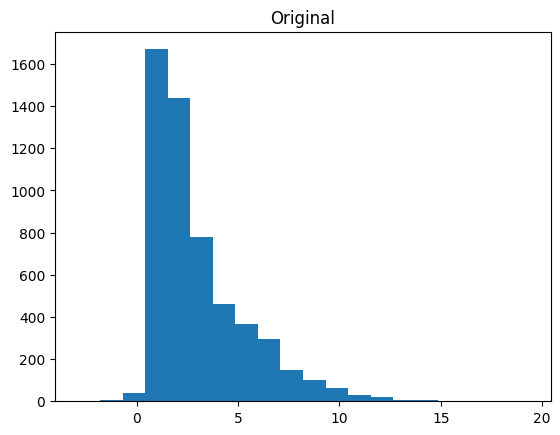

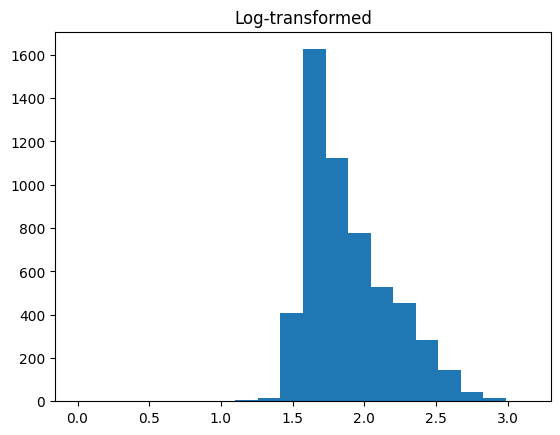


Log-transformation of the target is not applied



,NEE_L3.3_CUT_50_QCF0,SW_IN_POT,prec,ta,ppfd,sw_in,rh,timesince_prec,vpd,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,...,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-22 15:15:00,1.427440,277.0860,0.000,3.160000,32.345077,16.666667,91.736666,8.0,0.063359,4.183253,7.010251,7.412297,48.625304,56.253294,46.223418,...,0.524015,1.260472,-0.410443,-0.109809,0.746184,-0.980362,0.760726,1.700008,0.0,0.0,0.0,0.0,0.0,30.0,702
2023-11-22 15:45:00,1.002807,189.1070,0.000,2.983333,33.735705,17.333333,91.379999,9.0,0.065269,4.265979,7.243870,7.360901,48.839780,56.134146,46.352603,...,0.608953,1.644100,-1.043817,-0.057817,0.555294,-0.439485,0.204556,1.585453,0.0,0.0,0.0,0.0,0.0,30.0,703
2023-11-22 16:15:00,1.405169,91.8094,0.017,2.693333,10.790348,6.333333,92.029999,0.0,0.059114,4.135543,7.615964,7.423162,48.680861,56.298484,45.867126,...,0.529076,1.554913,-0.150715,0.065239,0.717598,-0.121607,-0.801852,1.026511,0.0,0.0,0.0,0.0,0.0,30.0,704
2023-11-22 16:45:00,1.052631,20.5151,0.017,2.593333,2.446582,2.333333,91.653332,0.0,0.061468,3.896637,6.400778,7.446704,48.255124,56.380921,45.857251,...,0.647230,1.133467,-0.145347,0.291490,0.747449,-0.333135,0.310568,0.461955,0.0,0.0,0.0,0.0,0.0,30.0,705
2023-11-22 17:15:00,1.088705,0.0000,0.000,2.506667,0.000000,0.000000,90.480000,1.0,0.069676,3.679415,6.489111,8.012857,48.267731,56.433886,45.820050,...,1.371347,0.552128,0.154700,0.345785,0.862861,-0.899240,-0.037856,0.678603,0.0,0.0,0.0,0.0,0.0,30.0,706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,10.578562,0.0000,0.017,15.693333,0.000000,0.000000,82.700000,0.0,0.308913,18.192778,18.566111,17.300000,47.839156,49.728310,45.159003,...,-0.862990,-1.240195,-0.138894,-0.501428,-0.865616,-0.130630,-0.951387,-1.460515,0.0,0.0,0.0,0.0,0.0,30.0,27595
2025-06-04 22:15:00,9.416519,0.0000,0.034,15.516667,0.000000,0.000000,84.423333,0.0,0.275008,18.041666,18.451111,17.300000,47.841354,49.728310,45.154540,...,-0.850980,-1.201306,-0.115306,-0.455520,-0.859899,-0.075635,-0.878298,-1.447001,0.0,0.0,0.0,0.0,0.0,30.0,27596
2025-06-04 22:45:00,10.095010,0.0000,0.425,15.660000,0.000000,0.000000,83.819999,0.0,0.288298,17.903888,18.398333,17.269444,47.829346,49.721516,45.105104,...,-0.847119,-1.197830,-0.108815,-0.438437,-0.860283,-0.205865,-0.852473,-1.503494,0.0,0.0,0.0,0.0,0.0,30.0,27597


In [7]:
min_value = data[TARGET].min()

def log_transform(x):
    return np.log1p(x - min_value) if min_value < 0 else np.log1p(x)

def inverse_log_transform(x):
    return np.expm1(x) + min_value if min_value < 0 else np.expm1(x)

# Show histogram of non-tranformed and transformed TARGET
plt.hist(data[TARGET], bins=20)
plt.title('Original')
plt.show()
plt.hist(log_transform(data[TARGET]), bins=20)
plt.title('Log-transformed')
plt.show()

if LOG_TRANSFORM:
    print('Log-tranformed')
    data[TARGET] = log_transform(data[TARGET])
    print(f'{TARGET} was log-transformed')
    # Show log-transformed timeseries
    data[TARGET].plot(x_compat=True, style='.', title='Log-transformed');
else:
    print('\nLog-transformation of the target is not applied\n')

data

# CROSS-VAL SPLITS


Using time-blocks (6 records on average) splits for cross-validation



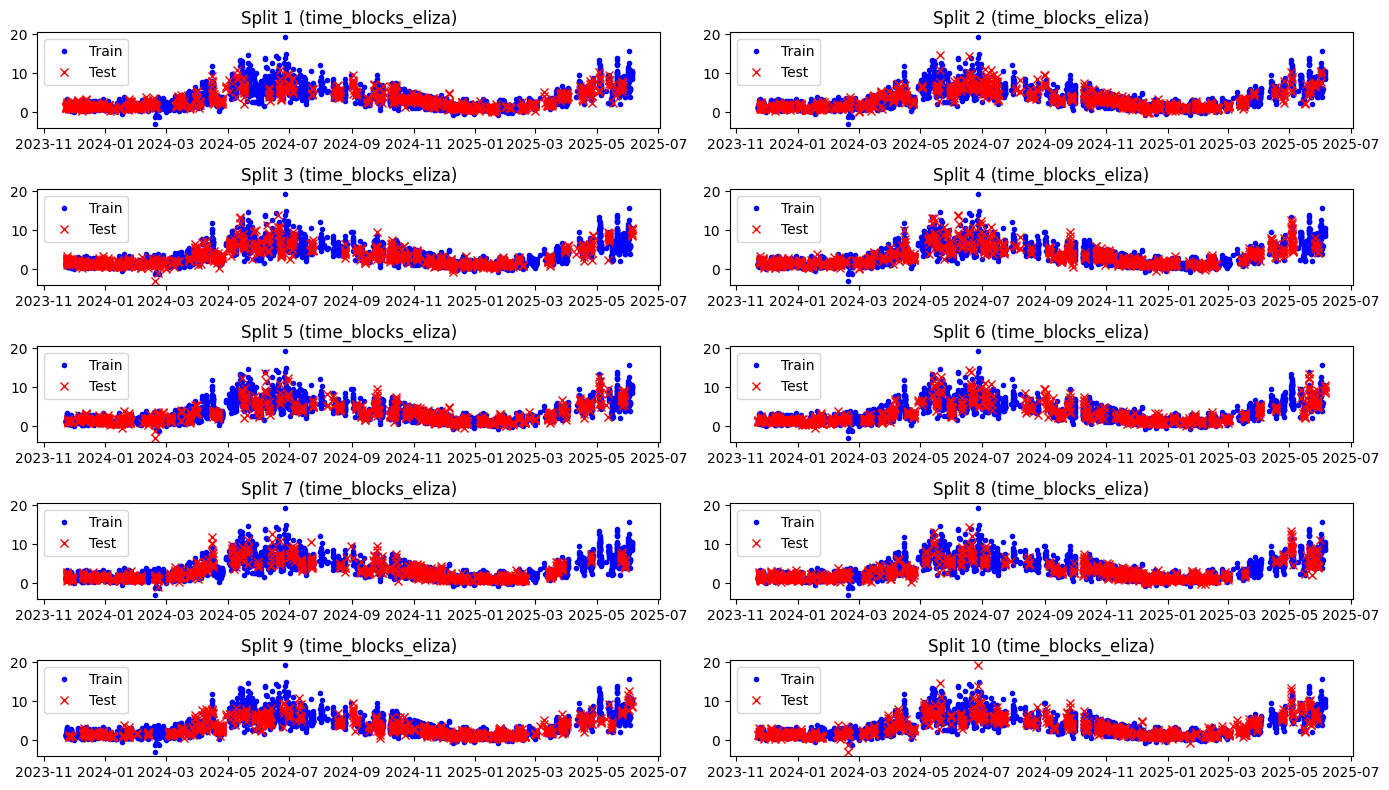

In [8]:
def create_splits(X, y, n_folds, test_size=0.2, random_state=42, n_bins=5):
    """Creates train-test splits using StratifiedShuffleSplit or StratifiedKFold with equal-width binning."""
    
    # Use pd.cut to create equal-width bins (avoids empty bins issue)
    y_binned = pd.cut(y, bins=n_bins, labels=False, include_lowest=True)

    # Select method for stratified splitting
    if CROSSVAL_SPLIT == "shuffle":
        splitter = StratifiedShuffleSplit(n_splits=n_folds, test_size=test_size, random_state=random_state)
        print('\nUsing stratified random splits for cross-validation\n')
    elif CROSSVAL_SPLIT == "kfold":
        splitter = StratifiedKFold(n_splits=n_folds, shuffle=False)
        print('\nUsing stratified kfold splits for cross-validation\n')

    # Generate train-test splits
    splits = [(train_idx, test_idx) for train_idx, test_idx in splitter.split(X, y_binned)]

    return splits

if CROSSVAL_SPLIT == 'time_blocks_eliza':
    block_size = 6 
    print(f'\nUsing time-blocks ({block_size} records on average) splits for cross-validation\n')
    def create_splits(X, y, n_folds, split=0.2, mean_block=block_size, min_block=1, random_state=42): # you can set mean block to mean_nan_size
        """Generates multiple train-test index splits using block-based cross-validation by varying the random seed."""
        splits = []
        total_test = round(len(X) * split)
        n_blocks = round(total_test/mean_block)

        if mean_block < min_block:
            raise ValueError("Min block size is too large for the number of blocks.")

        for fold in range(n_folds):
            np.random.seed(random_state + fold)  # Change seed for each fold
            
            tt = np.zeros(len(X))  # Array to store train-test assignments

            # Generate random block sizes with normal variation
            blocks = np.array([max(min_block, mean_block + round(v)) 
                            for v in np.random.normal(0, mean_block / 10, n_blocks)])

            # Randomly shuffle the starting positions of test blocks
            available_positions = np.arange(len(X))  # Possible start positions
            np.random.shuffle(available_positions)   # Shuffle them

            # Assign blocks sequentially based on shuffled positions
            assigned = set()
            for b in blocks:
                if len(assigned) >= total_test:
                    break
                # Pick a random starting position
                istart = np.random.choice(available_positions)
                iend = min(istart + int(b), len(X))

                # Ensure blocks don't overlap significantly
                assigned.update(range(istart, iend))
                tt[istart:iend] = 1

            train_idx = np.where(tt == 0)[0]
            test_idx = np.where(tt == 1)[0]
            
            splits.append((train_idx, test_idx))

        return splits

X = data.drop(columns=TARGET)
y = data[TARGET]
# Create the splits using StratifiedShuffleSplit
cross_val_splits = create_splits(X, y, n_folds=N_FOLDS)


# --- PLOT TRAIN-TEST SPLITS ---
n_rows = math.ceil(N_FOLDS / 2)  # Ensure enough rows for all splits
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 8))
axes = axes.flatten()  # Flatten the axes array to make iteration easier

for i, (train_idx, test_idx) in enumerate(cross_val_splits):
    train_idx_mapped = X.iloc[train_idx].index
    test_idx_mapped = X.iloc[test_idx].index

    # Plot train and test points
    axes[i].plot(y.loc[train_idx_mapped].index, y.loc[train_idx_mapped], '.', label='Train', color="blue")
    axes[i].plot(y.loc[test_idx_mapped].index, y.loc[test_idx_mapped], 'x', label='Test', color="red")
    
    axes[i].set_title(f"Split {i + 1} ({CROSSVAL_SPLIT})")
    axes[i].legend()

# Hide unused subplots if n_folds is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# FEATURE SELECTION

## Permutation importance

In [9]:
N_REPEATS = 5
N_RANDOMS = 10
def permutation_importance_selection(X, y, n_repeats=N_REPEATS, n_randoms=N_RANDOMS):
    iteration = 0
    # Generate random features ONCE and keep them throughout the iterations
    np.random.seed(42)  # Ensures reproducibility
    for i in range(n_randoms):
        X[f'random_{i}'] = np.random.permutation(len(X))

    while True:
        iteration += 1
        print(f"Iteration {iteration}: Starting with {X.shape[1] - n_randoms} features")

        model = RandomForestRegressor(n_estimators=100, min_samples_split=10, min_samples_leaf=5, random_state=42, n_jobs=-1) \
            if MODEL_TYPE == 'RandomForest' else XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        importance_scores, rmse_scores, r2_scores = [], [], []

        for train_idx, test_idx in cross_val_splits:
            X_train, y_train, X_test, y_test = X.iloc[train_idx], y.iloc[train_idx], X.iloc[test_idx], y.iloc[test_idx]
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            # Invert the transformation if it was applied to calculate the performance with the original scale
            if LOG_TRANSFORM:
                y_test, y_pred = inverse_log_transform(y_test), inverse_log_transform(y_pred)

            perm_importance = permutation_importance(model, X_test, y_test, n_repeats=n_repeats, random_state=42, n_jobs=-1)
            importance_scores.append(perm_importance.importances_mean)
            rmse_scores.append(root_mean_squared_error(y_test, y_pred))
            r2_scores.append(r2_score(y_test, y_pred))

        mean_importance = np.mean(importance_scores, axis=0)
        threshold = np.mean(mean_importance[-n_randoms:])  # Use average of random features as threshold
        
        to_remove = [col for col in X.columns if mean_importance[X.columns.get_loc(col)] < threshold and not col.startswith('random_')]
        to_keep = [col for col in X.columns if col not in to_remove]
        print(f"Iteration {iteration}: Removed {len(to_remove)} features, RMSE: {np.mean(rmse_scores):.4f}, R²: {np.mean(r2_scores):.4f}")
        
        if len(to_remove) == 0:
            break  # Stop when no features are removed

        X = X[to_keep].copy()

    # Remove random features from final selection
    to_keep = [col for col in to_keep if not col.startswith('random_')]
    return to_keep

if PERMUTATION_SEL:
    to_keep = permutation_importance_selection(data.drop(columns=[TARGET]), data[TARGET])
    data = data[to_keep + [TARGET]]
    to_keep
else:
    print('Permutation importance based feature removal is not applied')

Permutation importance based feature removal is not applied


## Recursive feature elimination

Iteration 1: Remaining features: 162, Removed: crop, RMSE: 0.9375, R²: 0.8230
Iteration 2: Remaining features: 161, Removed: prec, RMSE: 0.9376, R²: 0.8230
Iteration 3: Remaining features: 160, Removed: prec_lag6h, RMSE: 0.9427, R²: 0.8210
Iteration 4: Remaining features: 159, Removed: prec_lag9h, RMSE: 0.9430, R²: 0.8208
Iteration 5: Remaining features: 158, Removed: prec_lag3h, RMSE: 0.9376, R²: 0.8229
Iteration 6: Remaining features: 157, Removed: prec_lag3h_roll6hsum, RMSE: 0.9440, R²: 0.8206
Iteration 7: Remaining features: 156, Removed: prec_lag6h_roll3hsum, RMSE: 0.9383, R²: 0.8227
Iteration 8: Remaining features: 155, Removed: wfps_0.05_gfXG_roll9hmean, RMSE: 0.9367, R²: 0.8232
Iteration 9: Remaining features: 154, Removed: wfps_0.15_gfXG_roll3hmean, RMSE: 0.9331, R²: 0.8246
Iteration 10: Remaining features: 153, Removed: wfps_0.15_gfXG_lag9h_roll3hmean, RMSE: 0.9372, R²: 0.8231
Iteration 11: Remaining features: 152, Removed: prec_lag9h_roll3hsum, RMSE: 0.9371, R²: 0.8231
Itera

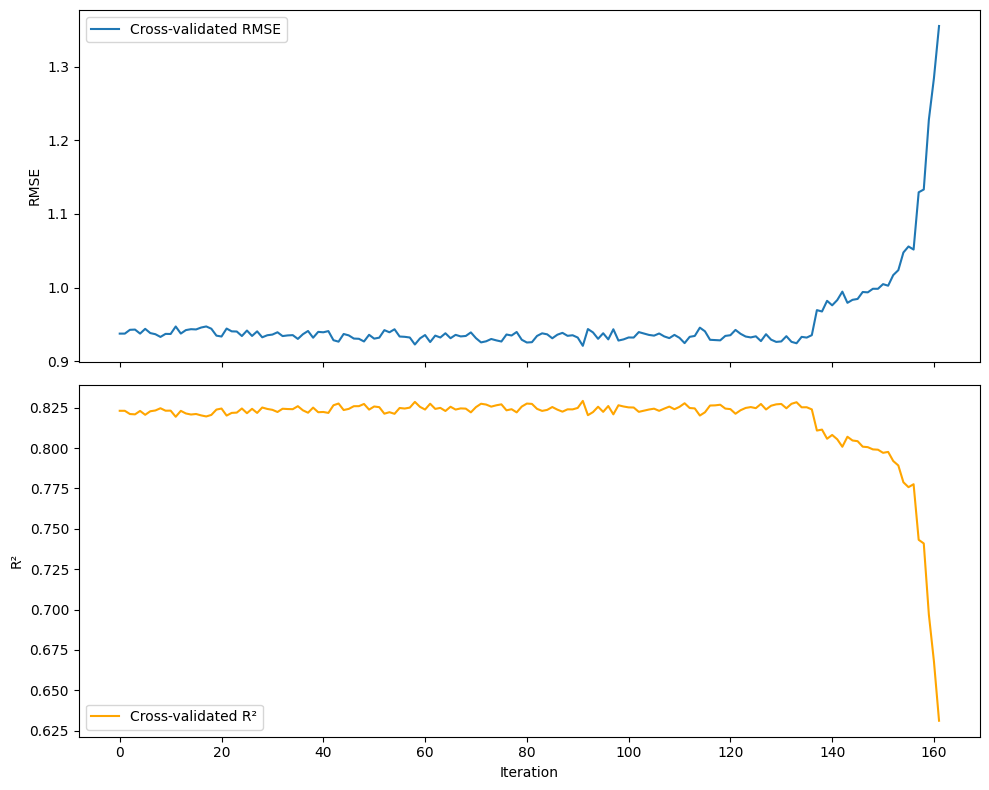


Best feature set found at iteration 134:
Selected Features: ['sw_in', 'timesince_soil_preparation', 'timesince_harvest', 'timesince_sowing', 'ta_roll3hmean', 'ts_0.15_gfXG_roll3hmean', 'ts_0.15_gfXG_roll6hmean', 'ts_0.15_gfXG_roll9hmean', 'ts_0.3_gfXG_roll3hmean', 'wfps_0.3_gfXG_roll3hmean', 'wfps_0.3_gfXG_roll6hmean', 'wfps_0.3_gfXG_roll9hmean', 'ta_lag3h_roll9hmean', 'ta_lag6h_roll3hmean', 'ta_lag6h_roll6hmean', 'ts_0.05_gfXG_lag3h_roll3hmean', 'ts_0.05_gfXG_lag3h_roll6hmean', 'ts_0.05_gfXG_lag3h_roll9hmean', 'ts_0.05_gfXG_lag6h_roll3hmean', 'ts_0.15_gfXG_lag3h_roll3hmean', 'ts_0.15_gfXG_lag3h_roll6hmean', 'ts_0.3_gfXG_lag3h_roll3hmean', 'ts_0.3_gfXG_lag6h_roll9hmean', 'ts_0.3_gfXG_lag9h_roll9hmean', 'wfps_0.05_gfXG_lag6h_roll9hmean', 'wfps_0.15_gfXG_lag3h_roll6hmean', 'ts_0.3_gfXG_diff12h', 'wfps_0.15_gfXG_diff24h', 'n_decay_timed', 'id']
Performance - RMSE: 0.9245, R²: 0.8283


In [10]:
def rfe_selection(X, y, cross_val_splits):
    performance = []
    iteration = 0
    features = list(X.columns)
    feature_removal_order = []  # Store removed features and their iteration index

    while len(features) > 1:
        iteration += 1
        rmse_scores, r2_scores, importances = [], [], []

        for train_idx, test_idx in cross_val_splits:
            X_train, y_train, X_test, y_test = X[features].iloc[train_idx], y.iloc[train_idx], X[features].iloc[test_idx], y.iloc[test_idx]
            model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) if MODEL_TYPE == 'RandomForest' else XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            # Invert the transformation if it was applied to calculate the performance with the original scale
            if LOG_TRANSFORM:
                y_test, y_pred = inverse_log_transform(y_test), inverse_log_transform(y_pred)
            
            rmse_scores.append(root_mean_squared_error(y_test, y_pred))
            r2_scores.append(r2_score(y_test, y_pred))
            importances.append(model.feature_importances_)

        mean_rmse = np.mean(rmse_scores)
        mean_r2 = np.mean(r2_scores)
        performance.append((features.copy(), mean_rmse, mean_r2))

        mean_importances = np.mean(importances, axis=0)
        least_important_index = np.argmin(mean_importances)
        least_important_feature = features.pop(least_important_index)

        # Store the removed feature with its iteration index
        feature_removal_order.append((least_important_feature, iteration))

        print(f"Iteration {iteration}: Remaining features: {len(features)}, Removed: {least_important_feature}, RMSE: {mean_rmse:.4f}, R²: {mean_r2:.4f}")

    # Extract RMSE and R² values
    rmse_values = [score[1] for score in performance]
    r2_values = [score[2] for score in performance]

    # Plot RMSE and R² over iterations
    fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    axs[0].plot(range(len(performance)), rmse_values, label="Cross-validated RMSE")
    axs[0].set_ylabel("RMSE")
    axs[0].legend()

    axs[1].plot(range(len(performance)), r2_values, label="Cross-validated R²", color="orange")
    axs[1].set_xlabel("Iteration")
    axs[1].set_ylabel("R²")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

    # Select best feature set by minimizing both R² and RMSE and penlizing larger feature sets
    # Normalize RMSE and R²
    norm_rmse = (np.array(rmse_values) - min(rmse_values)) / (max(rmse_values) - min(rmse_values))
    norm_r2 = (np.array(r2_values) - min(r2_values)) / (max(r2_values) - min(r2_values))
    # Set weights for normalized metrics
    w_rmse, w_r2, w_penalty = 0.5, 0.5, 0.001  # Adjust w_penalty as needed
    # Calculate composite scores with normalized metrics and feature count penalty
    composite_scores = [
        (performance[i][0], # Features
         i + 1, # Iteration number
        w_rmse * norm_rmse[i] + w_r2 * (1 - norm_r2[i]) + w_penalty * len(performance[i][0])  # Composite score
        )  
        for i in range(len(performance))
    ]

    # Find the feature subset with the best (lowest) composite score
    best_features, best_iteration, _ = min(composite_scores, key=lambda x: x[2])

    # Add the final remaining feature
    feature_removal_order.append((features[0], iteration + 1))

    # Rank features based on removal order
    feature_ranking = [feature for feature, _ in sorted(feature_removal_order, key=lambda x: x[1], reverse=True)]

    # Print the best feature set details
    print(f"\nBest feature set found at iteration {best_iteration}:")
    print(f"Selected Features: {best_features}")
    print(f"Performance - RMSE: {rmse_values[best_iteration-1]:.4f}, R²: {r2_values[best_iteration-1]:.4f}")

    return best_features, feature_ranking

if RFE_SEL:
    selected_features, ranked_features = rfe_selection(data.drop(columns=[TARGET]), data[TARGET], cross_val_splits= cross_val_splits)
    # Update the main dataframe
    data = data[selected_features + [TARGET]]
else:
    print('Recursive Feature Elimination is not applied')

# EXPORT 

In [11]:
filename = 'best_features_' + TARGET_FLUX + '_' + DAY_NIGHT + '_' + MODEL_TYPE + '.txt'
with open(filename, 'w') as f:
    for item in selected_features:
        f.write(f"{item}\n")

filename = 'ranked_features_' + TARGET_FLUX + '_' + DAY_NIGHT + '_' + MODEL_TYPE + '.txt'
with open(filename, 'w') as f:
    for item in ranked_features:
        f.write(f"{item}\n")

# **End of notebook**

In [12]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2025-10-30 17:54:51
